<a href="https://colab.research.google.com/github/devanshsri1612-bit/mle_case_study_1/blob/main/mle_cs_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    RocCurveDisplay
)

In [ ]:
np.random.seed(42)

n = 1000

data = pd.DataFrame({
    'age': np.random.randint(20, 90, n),
    'heart_rate': np.random.randint(60, 120, n),
    'blood_pressure': np.random.randint(90, 180, n),
    'prior_visits': np.random.randint(0, 10, n),
    'diagnosis_code': np.random.randint(1, 6, n)
})

data['readmitted'] = (
    (data['prior_visits'] > 4) |
    (data['heart_rate'] > 100) |
    (data['blood_pressure'] > 150)
).astype(int)

data.head()

,age,heart_rate,blood_pressure,prior_visits,diagnosis_code,readmitted
0,71,69,178,0,5,1
1,34,66,139,3,5,0
2,80,92,118,8,1,1
3,40,82,146,3,3,0
4,43,80,128,1,2,0


In [ ]:
print("Dataset Shape:", data.shape)
print("\nDataset Information:")
print(data.info())

print("\nFirst 5 Rows:")
print(data.head())

Dataset Shape: (1000, 6)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             1000 non-null   int64
 1   heart_rate      1000 non-null   int64
 2   blood_pressure  1000 non-null   int64
 3   prior_visits    1000 non-null   int64
 4   diagnosis_code  1000 non-null   int64
 5   readmitted      1000 non-null   int64
dtypes: int64(6)
memory usage: 47.0 KB
None

First 5 Rows:
   age  heart_rate  blood_pressure  prior_visits  diagnosis_code  readmitted
0   71          69             178             0               5           1
1   34          66             139             3               5           0
2   80          92             118             8               1           1
3   40          82             146             3               3           0
4   43          80             128             1            

In [ ]:
X = data.drop('readmitted', axis=1)
y = data['readmitted']

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   age  heart_rate  blood_pressure  prior_visits  diagnosis_code
0   71          69             178             0               5
1   34          66             139             3               5
2   80          92             118             8               1
3   40          82             146             3               3
4   43          80             128             1               2

Target:
0    1
1    0
2    1
3    0
4    0
Name: readmitted, dtype: int64


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 800
Testing Samples: 200


In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Feature Scaling Completed")

Feature Scaling Completed


In [ ]:
model = LogisticRegression(
    penalty='l2',
    C=1.0,
    solver='lbfgs',
    max_iter=1000
)

model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


In [ ]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:, 1]

print("Predictions Generated")

Predictions Generated


In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.875


In [ ]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[ 31  16]
 [  9 144]]


In [ ]:
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.66      0.71        47
           1       0.90      0.94      0.92       153

    accuracy                           0.88       200
   macro avg       0.84      0.80      0.82       200
weighted avg       0.87      0.88      0.87       200



In [ ]:
roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.9397858434153803


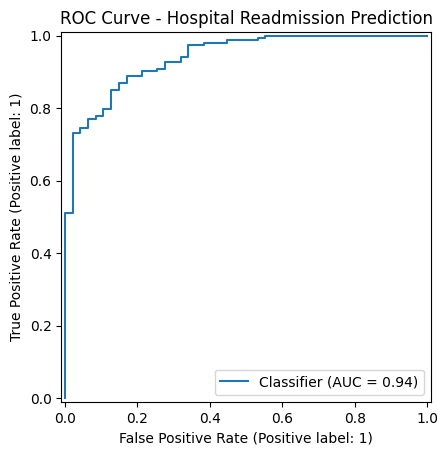

In [ ]:
RocCurveDisplay.from_predictions(y_test, y_prob)

plt.title("ROC Curve - Hospital Readmission Prediction")
plt.show()

In [ ]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

print(coefficients)

          Feature  Coefficient
0             age    -0.136872
1      heart_rate     1.564230
2  blood_pressure     1.678355
3    prior_visits     2.372811
4  diagnosis_code     0.057881
